In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=20

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Soybean Leaf Dataset for Disease Classification",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 345 files belonging to 7 classes.


In [4]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [5]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [6]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [8]:
# Apply data augmentation repeatedly to 
# generate more images
num_augmented = 3 
augmented_train_ds = train_ds.flat_map(lambda x, y: tf.data.Dataset.from_tensors((data_augmentation(x, training=True), y)).repeat(num_augmented))

# Lenent model

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define your LeNet model
def build_lenet(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create an instance of the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 7
model = build_lenet(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])




In [14]:
 #Train the model
history = model.fit(augmented_train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)


Epoch 1/20
24/24 [==============================] - 57s 2s/step - loss: 335.7280 - accuracy: 0.1823 - val_loss: 2.3802 - val_accuracy: 0.1875
Epoch 2/20
24/24 [==============================] - 17s 690ms/step - loss: 1.9101 - accuracy: 0.2839 - val_loss: 1.8583 - val_accuracy: 0.1875
Epoch 3/20
24/24 [==============================] - 17s 713ms/step - loss: 1.7533 - accuracy: 0.3177 - val_loss: 1.7872 - val_accuracy: 0.3125
Epoch 4/20
24/24 [==============================] - 17s 713ms/step - loss: 1.4820 - accuracy: 0.4961 - val_loss: 1.9268 - val_accuracy: 0.3125
Epoch 5/20
24/24 [==============================] - 17s 700ms/step - loss: 1.4078 - accuracy: 0.5729 - val_loss: 1.7950 - val_accuracy: 0.3125
Epoch 6/20
24/24 [==============================] - 17s 701ms/step - loss: 1.3991 - accuracy: 0.5182 - val_loss: 2.0201 - val_accuracy: 0.3125
Epoch 7/20
24/24 [==============================] - 17s 708ms/step - loss: 1.2196 - accuracy: 0.6172 - val_loss: 2.0761 - val_accuracy: 0.3438


In [15]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)

2/2 [==============================] - 18s 157ms/step - loss: 1.5474 - accuracy: 0.5938
Test Accuracy: 0.59375


In [16]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

In [17]:
import matplotlib.pyplot as plt

In [18]:
class_names=dataset.class_names

first image to predict
actual label: Frogeye Leaf Spot
1/1 [==============================] - 0s 277ms/step
predicted label: Sudden Death Syndrome


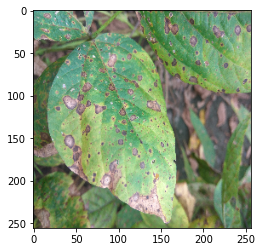

In [19]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

1/1 [==============================] - 0s 74ms/step


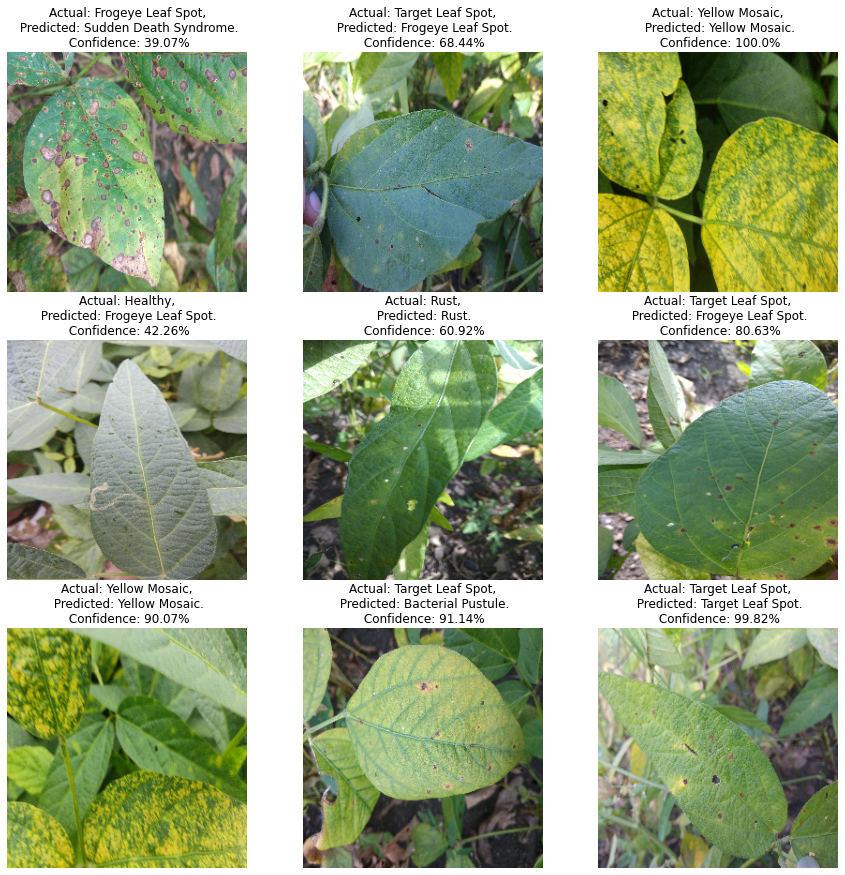

In [20]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

# Alexnet

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define your AlexNet model
def build_alexnet(input_shape, num_classes):
    model = models.Sequential([
        # First Convolutional Layer
        layers.Conv2D(96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        # Second Convolutional Layer
        layers.Conv2D(256, kernel_size=(5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        # Third Convolutional Layer
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        # Fourth Convolutional Layer
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        # Fifth Convolutional Layer
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        layers.Flatten(),
        # First Fully Connected Layer
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        # Second Fully Connected Layer
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create an instance of the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 7
model = build_alexnet(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(augmented_train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)


Epoch 1/20
24/24 [==============================] - 59s 2s/step - loss: 9.2111 - accuracy: 0.4180 - val_loss: 50765.8828 - val_accuracy: 0.1875
Epoch 2/20
24/24 [==============================] - 51s 2s/step - loss: 5.4614 - accuracy: 0.5000 - val_loss: 8284.4395 - val_accuracy: 0.1875
Epoch 3/20
24/24 [==============================] - 51s 2s/step - loss: 4.5890 - accuracy: 0.5117 - val_loss: 14973.9414 - val_accuracy: 0.1875
Epoch 4/20
24/24 [==============================] - 52s 2s/step - loss: 2.2800 - accuracy: 0.5456 - val_loss: 2273.5010 - val_accuracy: 0.1875
Epoch 5/20
24/24 [==============================] - 54s 2s/step - loss: 1.5646 - accuracy: 0.5326 - val_loss: 461.0490 - val_accuracy: 0.1875
Epoch 6/20
24/24 [==============================] - 53s 2s/step - loss: 1.3827 - accuracy: 0.5768 - val_loss: 860.3681 - val_accuracy: 0.1875
Epoch 7/20
24/24 [==============================] - 54s 2s/step - loss: 0.9785 - accuracy: 0.6745 - val_loss: 200.4919 - val_accuracy: 0.1875


# VGG NET

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define your VGG model
def build_vgg(input_shape, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        
        # Block 2
        layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        
        # Block 3
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        
        # Block 4
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        
        # Block 5
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create an instance of the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 7
model = build_vgg(input_shape, num_classes)

In [10]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# GoogleNet

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define your GoogleNet (Inception V1) model
def build_googlenet(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_layer)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same', activation='relu')(x)
    x = layers.Conv2D(192, (3, 3), strides=(1, 1), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception blocks
    x = inception_module(x, filters=[64, 96, 128, 16, 32, 32], name='inception_3a')
    x = inception_module(x, filters=[128, 128, 192, 32, 96, 64], name='inception_3b')
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, filters=[192, 96, 208, 16, 48, 64], name='inception_4a')
    x = inception_module(x, filters=[160, 112, 224, 24, 64, 64], name='inception_4b')
    x = inception_module(x, filters=[128, 128, 256, 24, 64, 64], name='inception_4c')
    x = inception_module(x, filters=[112, 144, 288, 32, 64, 64], name='inception_4d')
    x = inception_module(x, filters=[256, 160, 320, 32, 128, 128], name='inception_4e')
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, filters=[256, 160, 320, 32, 128, 128], name='inception_5a')
    x = inception_module(x, filters=[384, 192, 384, 48, 128, 128], name='inception_5b')

    # Top
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output_layer, name='googlenet')
    return model

# Helper function to create an Inception module
def inception_module(x, filters, name):
    f1, f2, f3, f4, f5, f6 = filters

    # 1x1 Convolution
    conv1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    # 1x1 Convolution followed by 3x3 Convolution
    conv3 = layers.Conv2D(f2, (1, 1), padding='same', activation='relu')(x)
    conv3 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(conv3)

    # 1x1 Convolution followed by 5x5 Convolution
    conv5 = layers.Conv2D(f4, (1, 1), padding='same', activation='relu')(x)
    conv5 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(conv5)

    # 3x3 MaxPooling followed by 1x1 Convolution
    pool = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool = layers.Conv2D(f6, (1, 1), padding='same', activation='relu')(pool)

    # Concatenate the outputs
    output = layers.Concatenate(axis=-1)([conv1, conv3, conv5, pool])
    return output

# Create an instance of the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 7
model = build_googlenet(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(augmented_train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)


Epoch 1/20
24/24 [==============================] - 114s 4s/step - loss: 2.1194 - accuracy: 0.1589 - val_loss: 1.9572 - val_accuracy: 0.1875
Epoch 2/20
24/24 [==============================] - 76s 3s/step - loss: 1.9506 - accuracy: 0.1549 - val_loss: 1.9637 - val_accuracy: 0.0312
Epoch 3/20
24/24 [==============================] - 77s 3s/step - loss: 1.9482 - accuracy: 0.1523 - val_loss: 1.9375 - val_accuracy: 0.0938
Epoch 4/20
24/24 [==============================] - 78s 3s/step - loss: 1.9248 - accuracy: 0.1849 - val_loss: 1.9560 - val_accuracy: 0.0938
Epoch 5/20
24/24 [==============================] - 80s 3s/step - loss: 1.9300 - accuracy: 0.1706 - val_loss: 1.8534 - val_accuracy: 0.2500
Epoch 6/20
24/24 [==============================] - 86s 4s/step - loss: 1.8049 - accuracy: 0.2695 - val_loss: 1.4502 - val_accuracy: 0.4062
Epoch 7/20
24/24 [==============================] - 96s 4s/step - loss: 1.6804 - accuracy: 0.2852 - val_loss: 1.5038 - val_accuracy: 0.4062
Epoch 8/20
24/24 [=

# Lest NeT

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define a basic residual block
def residual_block(x, filters, strides=(1, 1), use_projection=False):
    shortcut = x
    if use_projection:
        shortcut = layers.Conv2D(filters, (1, 1), strides=strides, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, (3, 3), strides=strides, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# Define your ResNet model
def build_resnet(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)

    x = residual_block(x, filters=128, strides=(2, 2), use_projection=True)
    x = residual_block(x, filters=128)

    x = residual_block(x, filters=256, strides=(2, 2), use_projection=True)
    x = residual_block(x, filters=256)

    x = residual_block(x, filters=512, strides=(2, 2), use_projection=True)
    x = residual_block(x, filters=512)

    x = layers.GlobalAveragePooling2D()(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output_layer, name='resnet')
    return model

# Create an instance of the model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 7
model = build_resnet(input_shape, num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)


Epoch 1/20
8/8 [==============================] - 50s 6s/step - loss: 2.9148 - accuracy: 0.2695 - val_loss: 5030.8418 - val_accuracy: 0.1875
Epoch 2/20
8/8 [==============================] - 39s 5s/step - loss: 1.6351 - accuracy: 0.4492 - val_loss: 44595.6953 - val_accuracy: 0.1875
Epoch 3/20
8/8 [==============================] - 41s 5s/step - loss: 1.0789 - accuracy: 0.5938 - val_loss: 119484.0000 - val_accuracy: 0.0938
Epoch 4/20
8/8 [==============================] - 43s 5s/step - loss: 0.8497 - accuracy: 0.6953 - val_loss: 32335.0840 - val_accuracy: 0.1875
Epoch 5/20
8/8 [==============================] - 42s 5s/step - loss: 0.7574 - accuracy: 0.7344 - val_loss: 9385.6074 - val_accuracy: 0.0938
Epoch 6/20
8/8 [==============================] - 43s 5s/step - loss: 0.6435 - accuracy: 0.7578 - val_loss: 3974.1721 - val_accuracy: 0.0938
Epoch 7/20
8/8 [==============================] - 42s 5s/step - loss: 0.5688 - accuracy: 0.8047 - val_loss: 1765.0209 - val_accuracy: 0.0938
Epoch 8/2

# Model               Accuracy
LENET                60%

ALEXNET              30%

GOOGLENET            50%

LESTNET              15%

In [4]:
print ("The accuracy of LENET model ","60%")
print ("The accuracy of ALEXNET model ","30%")
print ("The accuracy of GOOGLENET model ","50%")
print("the accuracy of LESTNET", "15%")


The accuracy of LENET model  60%
The accuracy of ALEXNET model  30%
The accuracy of GOOGLENET model  50%
the accuracy of LESTNET 15%
